# AP 155 Lab Exercise
---
## Exercise 7: Root Finding

_Instructions_:
- **Report figure:** (See Problem) Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).
- **Report discussion:**
    - Explain the report figure.
    - What are the advantages and disadvantages of the root-finding methods?
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Luarez, Karl Andrei
- _Student No._: 2024-12430
- _Section_: THR-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 |
| Code appropriateness  | XX | 20 |
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

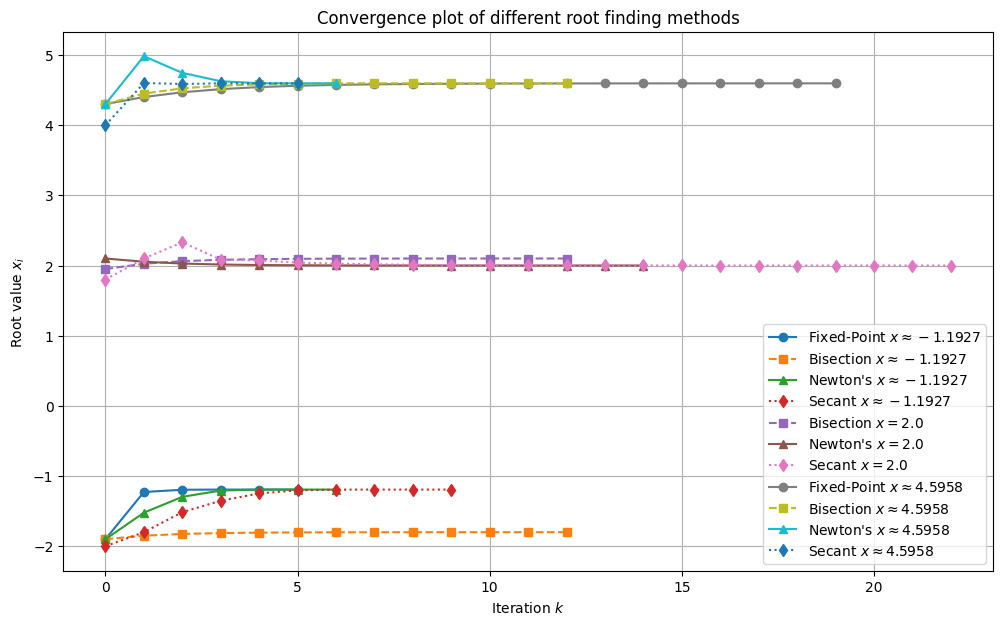

### Report discussion

The figure shows the convergence of different root finding methods in finding the three roots of $f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8$ namely $x\approx -1.1927, x\approx 4.5949$ and $x=2.0$. For the positive and negative roots, the Newton's and Secant converges faster compared to other methods. However, the fixed-point method converges faster at the negative root than at $x\approx 4.5959$. While the bisection method consistently converges for all roots with the same iterations. The root with multiplicity 2 at $x=2.0$ has a derivative of zero which causes the Newton's and secant method to converge slower, taking more iterations. However, the bisection method remains consistent with its iterations.

This shows that the advantage of using the bisection method is that it is convergent for all continuous intervals even for double roots albeit slower compared to the Newton's and secant method which converges faster at simple roots. The fixed-point iteration is straight-forward and simple but its weakness is its convergence that the derivative must be less than one near the root.

### Other comments
- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.


---
## Section 2: Code

In [155]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Root Finding


Implement root finders *manually* to find the roots of an arbitrary function

1. fixed-point method (relaxation, needs an initial guess)
2. bisection method (bracketing, needs two bounds)
3. newton's method (known derivative, needs an initial guess)
4. secant method (approximate derivative, needs two initial guesses)

Consider the function

$$
f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8
$$

5. Plot the function from x=-2 to x=-5. You may want to "enlarge" the plot by rescaling/"cropping" the y-axis. You should be able to estimate where the roots are approximately
   
6. Find the roots of $f(x)$ by implementing the four methods shown.

7. Report Figure: Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).

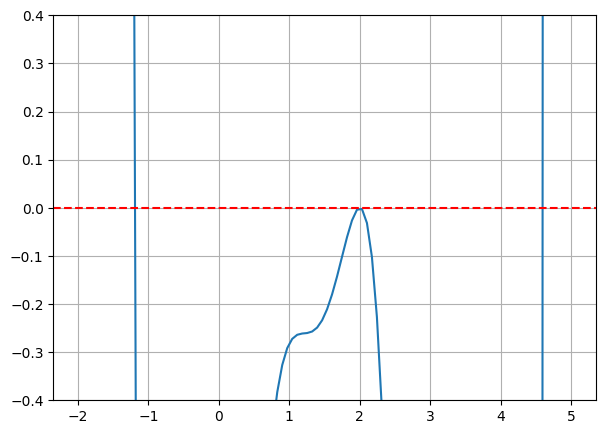

In [156]:
xs = np.linspace(-2, 5, 100)

def f(x):
  return -x**5 + 4*x**4 - 4*x**3 + x**2*np.exp(x) - 2*x**2 -4*x*np.exp(x) + 8*x + 4*np.exp(x) -8

figs, ax = plt.subplots(figsize=(7,5))
ax.plot(xs, f(xs))
ax.set_ylim(-0.4,0.4)
ax.axhline(y=0, color='r', linestyle='--')
ax.grid()
plt.show()

From the plot of $f(x)$, we can see that it has three roots. However this diverges due tot he exponentials and we encounter an overflow error. Therefore we rewrite $f(x)$.
$$
f(x) = (x-2)^2(e^x-x^3-2)
$$
(I admit that I used mathway for this).
Let
$$
h_1(x) = (x-2)^2
$$
$$
h_2(x) = e^x - x^3 - 2
$$
To find the roots of $f(x)$ using fixed-point iteration we apply it for each $h_1(x)$ and $h_2(x)$. Setting them equal to zero we get
$$
x = 2
$$
$$
x = \sqrt[3]{e^x-2} \space \text{or} \space x = \log(x^3+2)
$$
Define:
$$
g_1(x) = \sqrt[3]{e^x-2}
$$
$$
g_2(x) = \log(x^3+2)
$$
It is clear that one root is $x=2$ and applying fixed point iterration for this would be trivial.

In [157]:
# Fixed-point method

def g1(x):
  return np.cbrt(np.exp(x)-2)
def g2(x):
  return np.log(x**3+2)

def fixedpoint(f, xold, kmax=200, tol=1.e-5):
  fixed_xi = [xold]
  for k in range(1, kmax+1):
    xnew = f(xold)
    fixed_xi.append(xnew)

    xdiff = xnew - xold
    # print("{0:2d} {1:1.16f} {2:1.16f}".format(k, xnew, xdiff))
    if abs(xdiff/xnew) < tol:
      break
    xold = xnew
  else:
    xnew = None

  return xnew, fixed_xi

# Negative root
for xold in (-1.9,1.8):
  x, _ = fixedpoint(g1, xold)
  print(f"Negative root: {x}")

# Positive root
for xold in (4.3  ,4.7):
  x, _ = fixedpoint(g2, xold)
  print(f"Positive root: {x}")

for xold in (1.8, 2.2):
  x, _ =fixedpoint(f, xold)
  print(x)

Negative root: -1.1926866409995704
Negative root: -1.1926856906023537
Positive root: 4.595797286753408
Positive root: 4.595942878927835
None
None


/tmp/ipykernel_1176/1639715625.py:4: RuntimeWarning: overflow encountered in exp
  return -x**5 + 4*x**4 - 4*x**3 + x**2*np.exp(x) - 2*x**2 -4*x*np.exp(x) + 8*x + 4*np.exp(x) -8
/tmp/ipykernel_1176/1639715625.py:4: RuntimeWarning: invalid value encountered in scalar subtract
  return -x**5 + 4*x**4 - 4*x**3 + x**2*np.exp(x) - 2*x**2 -4*x*np.exp(x) + 8*x + 4*np.exp(x) -8


In [158]:
# Bisection Method

def bisection(f, x0, x1, kmax=200, tol=1.e-5):
  bisection_xi = []
  f0 = f(x0)
  for k in range(1, kmax):
    x2 = (x0 + x1)/2
    f2 = f(x2)
    bisection_xi.append(x2)

    if f0*f2 < 0:
      x1 = x2
    else:
      x0 = x2
      f0 = f2

    x2new = (x0 + x1)/2
    xdiff = abs(x2new - x2)
    # print("{0:2d} {1:1.16f} {2:1.16f} {3:1.16f}".format(k, x2new, xdiff, abs(f(x2new))))

    if abs(xdiff/x2new) < tol:
      break
  else:
    x2new = None

  return x2new, bisection_xi

guess_ranges = [
    (-2.0, -1.8),  # negative root
    (1.8, 2.1),    # x = 2
    (4.0, 4.6)     # positive root
]

for x0, x1 in guess_ranges:
    root, _  = bisection(f, x0, x1)
    print(f"Interval: {x0,x1}")
    print(f"Root: {root}")



Interval: (-2.0, -1.8)
Root: -1.80001220703125
Interval: (1.8, 2.1)
Root: 2.0999816894531254
Interval: (4.0, 4.6)
Root: 4.595861816406249


In [159]:
# Newton's Method
def df(x):
  return (-5*x**4) + (16*x**3) - (12*x**2) + (x**2 * np.exp(x)) - (2*x*np.exp(x)) - (4*x) + 8

def newtons(f, df, x0, kmax=200, tol=1.e-5):
  newtons_xi = [x0]
  for k in range(1, kmax):
    f0, df0 = f(x0), df(x0)
    if abs(df0) < tol:
      break # stop if zero derivative

    xnew = x0 - f0/df0
    newtons_xi.append(xnew)
    xdiff = xnew - x0

   # print("{0:2d} {1:1.16f} {2:1.16e} {3:1.16e}".format(k, xnew, f0, xdiff))
    if abs(xdiff) < tol:
      return xnew, newtons_xi

    x0 = xnew

  return xnew, newtons_xi

guess_values = [
    -1.9,  # negative root
    2.1,   # x=2
    4.3    # positive root
]

for x0 in guess_values:
    print(f"Initial guess: {x0}")
    root, _ = newtons(f, df, x0)
    print(f"Root: {root}")

Initial guess: -1.9
Root: -1.1926857650226288
Initial guess: 2.1
Root: 2.000007191518613
Initial guess: 4.3
Root: 4.595863564953279


In [160]:
# Secant Method

def secant(f, x0, x1, kmax=200, tol=1.e-5):
  secant_xi = [x0, x1]
  for k in range(1, kmax):
    f0, f1 = f(x0), f(x1)
    if abs(f1 - f0) < 1e-12:
      break

    xnew = (x1 - f1 * (x1-x0)/(f1-f0))
    xdiff = abs(xnew - x1)
    secant_xi.append(xnew)

   # print("{0:2d} {1:1.16f} {2:1.16e} {3:1.16e}".format(k, xnew, f0, xdiff))

    if xdiff < tol:
      break

    x0 = x1
    x1 = xnew

  return x1, secant_xi

interval_guess = [
    (-2.0, -1.8),  # negative root
    (1.8, 2.1),    # x = 2
    (4.0, 4.6)     # positive root
]

for x0, x1 in interval_guess:
    root, _ = secant(f, x0, x1)
    print(f"Interval: {x0, x1}")
    print(f"Root: {root:.16f}")

Interval: (-2.0, -1.8)
Root: -1.1926857874413757
Interval: (1.8, 2.1)
Root: 2.0000207908656247
Interval: (4.0, 4.6)
Root: 4.5958645770857700


/tmp/ipykernel_1176/1639715625.py:4: RuntimeWarning: overflow encountered in exp
  return -x**5 + 4*x**4 - 4*x**3 + x**2*np.exp(x) - 2*x**2 -4*x*np.exp(x) + 8*x + 4*np.exp(x) -8
/tmp/ipykernel_1176/1639715625.py:4: RuntimeWarning: invalid value encountered in scalar subtract
  return -x**5 + 4*x**4 - 4*x**3 + x**2*np.exp(x) - 2*x**2 -4*x*np.exp(x) + 8*x + 4*np.exp(x) -8


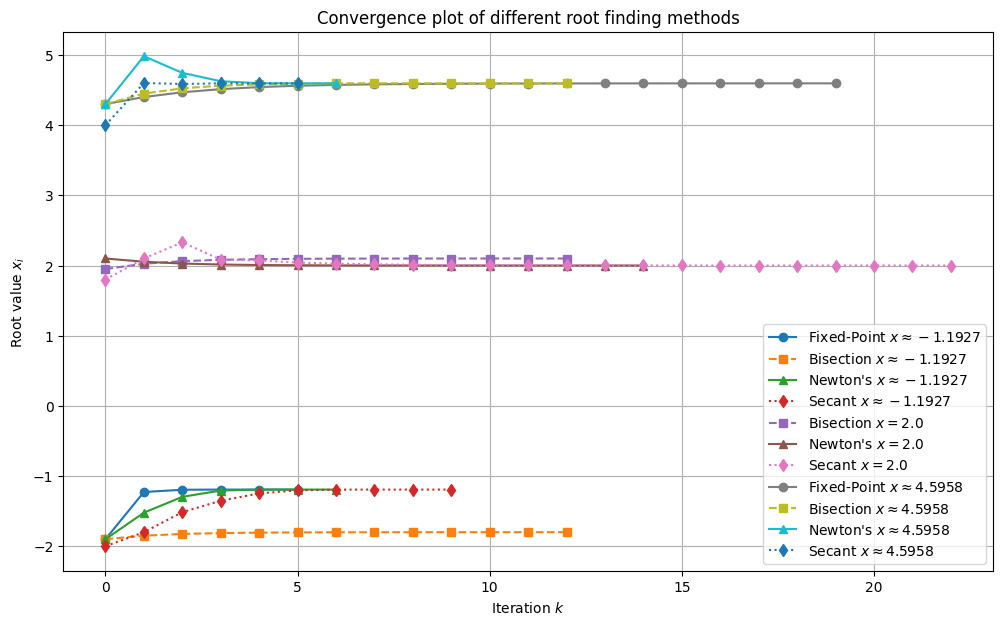

In [161]:
# Plotting

#xis per iterations
# Negative root interations (-1.1927)
fixedpoint_neg = fixedpoint(g1, -1.9)[1]
bisection_neg = bisection(f, -2.0, -1.8)[1]
newtons_neg = newtons(f, df, -1.9)[1]
secant_neg = secant(f, -2.0, -1.8)[1]

# Middle root (2.0)
fixedpoint_mid = fixedpoint(f, 2.1)[1]
bisection_mid = bisection(f, 1.8, 2.1)[1]
newtons_mid = newtons(f, df, 2.1)[1]
secant_mid = secant(f, 1.8, 2.1)[1]

# Positive root (4.5958)
fixedpoint_pos = fixedpoint(g2, 4.3)[1]
bisection_pos = bisection(f, 4.0, 4.6)[1]
newtons_pos = newtons(f, df, 4.3)[1]
secant_pos = secant(f, 4.0, 4.6)[1]


fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(fixedpoint_neg, label=r'Fixed-Point $x\approx -1.1927$', marker='o', linestyle='-')
ax.plot(bisection_neg, label=r'Bisection $x\approx -1.1927$', marker='s', linestyle='--')
ax.plot(newtons_neg, label=r"Newton's $x\approx -1.1927$", marker='^', linestyle='-')
ax.plot(secant_neg, label=r'Secant $x\approx -1.1927$', marker='d', linestyle=':')

# x=2 root curves
ax.plot(bisection_mid, label='Bisection $x=2.0$', marker='s', linestyle='--')
ax.plot(newtons_mid, label="Newton's $x=2.0$", marker='^', linestyle='-')
ax.plot(secant_mid, label='Secant $x=2.0$', marker='d', linestyle=':')

# positive root curves
ax.plot(fixedpoint_pos, label=r'Fixed-Point $x\approx 4.5958$', marker='o', linestyle='-')
ax.plot(bisection_pos, label=r'Bisection $x\approx 4.5958$', marker='s', linestyle='--')
ax.plot(newtons_pos, label=r"Newton's $x\approx 4.5958$", marker='^', linestyle='-')
ax.plot(secant_pos, label=r'Secant $x\approx 4.5958$', marker='d', linestyle=':')

ax.set_xlabel('Iteration $k$')
ax.set_ylabel('Root value $x_i$')
ax.set_title('Convergence plot of different root finding methods')
ax.legend()
ax.grid()
plt.show()

#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---

To avoid overflow errors in the fixed-point method, i refactored the original function $f(x)$ and rewrote them into a form $x=g(x)$ and used a $g_i(x)$ that satisfies $g_i'(x)< $ near the desired root to avoid these errors. The different root finding functions were also made with bounds such as abs(xold-xnew/xnew)< tol and a max number of iterrations to prevent infinite iterrations and stop running at potential divergence. I also defined an xi bin at each function to store the iterration history for plotting ${x_i}'s$ and the number of iterrations.